In [418]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pylab as pl
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

student_maths = pd.read_csv("./student_performance/student-mat.csv", sep= ';') # Targets of G1, G2, G3 main focus on G3
student_dropout = pd.read_csv("./student_performance/dropout_data.csv") # Target Col. is called "Target"
student_higher = pd.read_csv("./student_performance/higher_education_eval.csv") # Target Col. = "GRADE

dfs_targets = ['G3', 'Target', 'GRADE']
df_names = ['maths', 'dropout', 'higher']

In [420]:
from IPython.display import display_html
from itertools import chain,cycle
# Credit to ntg from https://stackoverflow.com/questions/38783027/jupyter-notebook-display-two-pandas-tables-side-by-side
def display_side_by_side(*args,titles=cycle([''])):
    html_str=''
    for df,title in zip(args, chain(titles,cycle(['</br>'])) ):
        html_str+='<th style="text-align:center"><td style="vertical-align:top">'
        html_str+=f'<h2 style="text-align: center;">{title}</h2>'
        html_str+=df.to_html().replace('table','table style="display:inline"')
        html_str+='</td></th>'
    display_html(html_str,raw=True)

In [422]:
display_side_by_side(student_maths.head(5), student_dropout.head(5),student_higher.head(5))
lst = student_maths.columns.tolist()

school 
 sex 
 age 
 address 
 famsize 
 Pstatus 
 Medu 
 Fedu 
 Mjob 
 Fjob 
 reason 
 guardian 
 traveltime 
 studytime 
 failures 
 schoolsup 
 famsup 
 paid 
 activities 
 nursery 
 higher 
 internet 
 romantic 
 famrel 
 freetime 
 goout 
 Dalc 
 Walc 
 health 
 absences 
 G1 
 G2 
 G3 
 
 
 
 
 0 
 GP 
 F 
 18 
 U 
 GT3 
 A 
 4 
 4 
 at_home 
 teacher 
 course 
 mother 
 2 
 2 
 0 
 yes 
 no 
 no 
 no 
 yes 
 yes 
 no 
 no 
 4 
 3 
 4 
 1 
 1 
 3 
 6 
 5 
 6 
 6 
 
 
 1 
 GP 
 F 
 17 
 U 
 GT3 
 T 
 1 
 1 
 at_home 
 other 
 course 
 father 
 1 
 2 
 0 
 no 
 yes 
 no 
 no 
 no 
 yes 
 yes 
 no 
 5 
 3 
 3 
 1 
 1 
 3 
 4 
 5 
 5 
 6 
 
 
 2 
 GP 
 F 
 15 
 U 
 LE3 
 T 
 1 
 1 
 at_home 
 other 
 other 
 mother 
 1 
 2 
 3 
 yes 
 no 
 yes 
 no 
 yes 
 yes 
 yes 
 no 
 4 
 3 
 2 
 2 
 3 
 3 
 10 
 7 
 8 
 10 
 
 
 3 
 GP 
 F 
 15 
 U 
 GT3 
 T 
 4 
 2 
 health 
 services 
 home 
 mother 
 1 
 3 
 0 
 no 
 yes 
 yes 
 yes 
 yes 
 yes 
 yes 
 yes 
 3 
 2 
 2 
 1 
 1 
 5 
 2 
 15 
 14 
 15 
 
 
 4 
 GP 
 F 
 16 
 U 
 GT3 
 T 
 3 
 3 
 other 
 other 
 home 
 father 
 1 
 2 
 0 
 no 
 yes 
 yes 
 no 
 yes 
 yes 
 no 
 no 
 4 
 3 
 2 
 1 
 2 
 5 
 4 
 6 
 10 
 10 
 
 
 
 
 
 
 Marital status 
 Application mode 
 Application order 
 Course 
 Daytime/evening attendance 
 Previous qualification 
 Previous qualification (grade) 
 Nacionality 
 Mother's qualification 
 Father's qualification 
 Mother's occupation 
 Father's occupation 
 Admission grade 
 Displaced 
 Educational special needs 
 Debtor 
 Tuition fees up to date 
 Gender 
 Scholarship holder 
 Age at enrollment 
 International 
 Curricular units 1st sem (credited) 
 Curricular units 1st sem (enrolled) 
 Curricular units 1st sem (evaluations) 
 Curricular units 1st sem (approved) 
 Curricular units 1st sem (grade) 
 Curricular units 1st sem (without evaluations) 
 Curricular units 2nd sem (credited) 
 Curricular units 2nd sem (enrolled) 
 Curricular units 2nd sem (evaluations) 
 Curricular units 2nd sem (approved) 
 Curricular units 2nd sem (grade) 
 Curricular units 2nd sem (without evaluations) 
 Unemployment rate 
 Inflation rate 
 GDP 
 Target 
 
 
 
 
 0 
 1 
 17 
 5 
 171 
 1 
 1 
 122.0 
 1 
 19 
 12 
 5 
 9 
 127.3 
 1 
 0 
 0 
 1 
 1 
 0 
 20 
 0 
 0 
 0 
 0 
 0 
 0.000000 
 0 
 0 
 0 
 0 
 0 
 0.000000 
 0 
 10.8 
 1.4 
 1.74 
 Dropout 
 
 
 1 
 1 
 15 
 1 
 9254 
 1 
 1 
 160.0 
 1 
 1 
 3 
 3 
 3 
 142.5 
 1 
 0 
 0 
 0 
 1 
 0 
 19 
 0 
 0 
 6 
 6 
 6 
 14.000000 
 0 
 0 
 6 
 6 
 6 
 13.666667 
 0 
 13.9 
 -0.3 
 0.79 
 Graduate 
 
 
 2 
 1 
 1 
 5 
 9070 
 1 
 1 
 122.0 
 1 
 37 
 37 
 9 
 9 
 124.8 
 1 
 0 
 0 
 0 
 1 
 0 
 19 
 0 
 0 
 6 
 0 
 0 
 0.000000 
 0 
 0 
 6 
 0 
 0 
 0.000000 
 0 
 10.8 
 1.4 
 1.74 
 Dropout 
 
 
 3 
 1 
 17 
 2 
 9773 
 1 
 1 
 122.0 
 1 
 38 
 37 
 5 
 3 
 119.6 
 1 
 0 
 0 
 1 
 0 
 0 
 20 
 0 
 0 
 6 
 8 
 6 
 13.428571 
 0 
 0 
 6 
 10 
 5 
 12.400000 
 0 
 9.4 
 -0.8 
 -3.12 
 Graduate 
 
 
 4 
 2 
 39 
 1 
 8014 
 0 
 1 
 100.0 
 1 
 37 
 38 
 9 
 9 
 141.5 
 0 
 0 
 0 
 1 
 0 
 0 
 45 
 0 
 0 
 6 
 9 
 5 
 12.333333 
 0 
 0 
 6 
 6 
 6 
 13.000000 
 0 
 13.9 
 -0.3 
 0.79 
 Graduate 
 
 
 
 
 
 
 STUDENT ID 
 AGE 
 SEX 
 GRADUATED_HS_TYPE 
 SCHOLARSHIP_TYPE 
 ADDITIONAL_WORK 
 REGULAR_SPORT_ART_ACTIVITY 
 PARTNER 
 TOTAL_SALARY 
 TRANSPORT_TO_CLASS 
 ACCOMODATION_TYPE 
 M_ED 
 F_ED 
 NUM_SIBLINGS 
 PARENTAL_STATUS 
 M_OCC 
 F_OCC 
 WEEKLY_STUDY_HRS 
 READING_FREQ_NONSCI 
 READING_FREQ_SCI 
 SEMINAR_ATTENDANCE 
 ATTITUDE_ON_PROJECTS 
 CLASS_ATTEND 
 MIDTERM_PREP_TYPE 
 MIDTERM_PREP_ROUTINE 
 NOTE_TAKING 
 CLASSROOM_ATTENTION 
 OPINION_ON_CLASSROOM_DISCUSSION 
 FLIP_CLASSROOM 
 CUM_GPA 
 EXPECTED_CUM_GPA 
 COURSE ID 
 GRADE 
 
 
 
 
 0 
 STUDENT1 
 2 
 2 
 3 
 3 
 1 
 2 
 2 
 1 
 1 
 1 
 1 
 2 
 3 
 1 
 2 
 5 
 3 
 2 
 2 
 1 
 1 
 1 
 1 
 1 
 3 
 2 
 1 
 2 
 1 
 1 
 1 
 1 
 
 
 1 
 STUDENT2 
 2 
 2 
 3 
 3 
 1 
 2 
 2 
 1 
 1 
 1 
 2 
 3 
 2 
 1 
 2 
 1 
 2 
 2 
 2 
 1 
 1 
 1 
 1 
 1 
 3 
 2 
 3 
 2 
 2 
 3 
 1 
 1 


In [424]:
student_higher = student_higher.drop(columns = ['STUDENT ID'])
student_maths = student_maths.drop(columns = ['G1', 'G2'])

le = LabelEncoder()
student_dropout['Target'] = le.fit_transform(student_dropout['Target'])

for i in lst:
    if student_maths[i].dtypes == object:
        student_maths[i] = le.fit_transform(student_maths[i])

student_higher.info()


KeyError: 'G1'

In [425]:
s_m_count = student_maths["G3"].value_counts().to_frame()
s_d_count = student_dropout["Target"].value_counts().to_frame()
s_h_count = student_higher["GRADE"].value_counts().to_frame()



display_side_by_side( s_d_count, s_h_count)
display(s_m_count)

,count
Target,
2,2209
0,1421
1,794
,count
GRADE,
1,35
2,24
3,21
5,17


,count
G3,
10,56
11,47
0,38
15,33
8,32
12,31
13,31
9,28
14,27


<Axes: xlabel='G3', ylabel='count'>

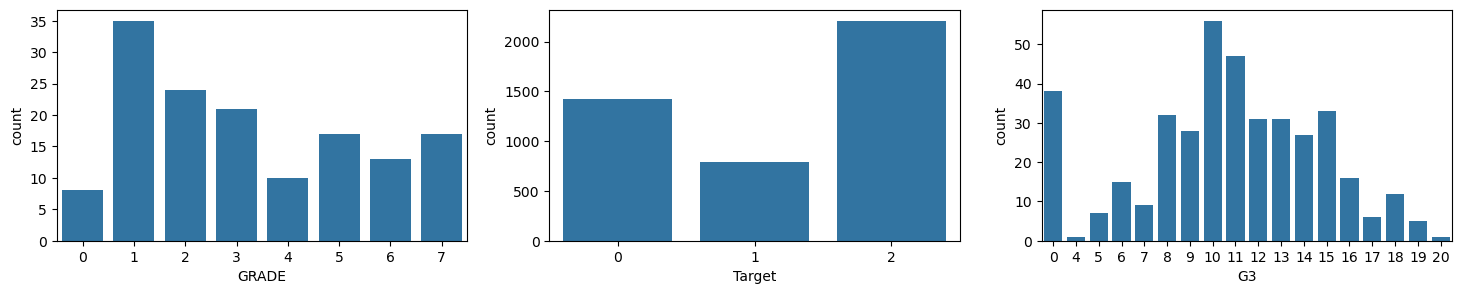

In [427]:
s_m_count = student_maths["G3"].value_counts().reset_index()
s_d_count = student_dropout["Target"].value_counts().reset_index()
s_h_count = student_higher["GRADE"].value_counts().reset_index()

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 3))

sns.barplot(x="GRADE", y="count",data=s_h_count, ax=axes[0])
sns.barplot(x="Target",y="count",data=s_d_count, ax=axes[1])
sns.barplot(x="G3", y="count" ,data=s_m_count, ax=axes[2])

In [429]:
def get_redundant_pairs(df):
    '''Get diagonal and lower triangular pairs of correlation matrix'''
    pairs_to_drop = set()
    cols = df.columns
    for i in range(0, df.shape[1]):
        for j in range(0, i+1):
            pairs_to_drop.add((cols[i], cols[j]))
    return pairs_to_drop

def get_top_abs_correlations(df, n=5):
    au_corr = df.corr().abs().unstack()
    labels_to_drop = get_redundant_pairs(df)
    au_corr = au_corr.drop(labels=labels_to_drop).sort_values(ascending=False)
    return au_corr[0:n]

dfs = [student_maths, student_dropout, student_higher]


for i in dfs:
    print("Top Absolute Correlations")
    print(get_top_abs_correlations(i, 5))

Top Absolute Correlations
Dalc    Walc    0.647544
Medu    Fedu    0.623455
        Mjob    0.454805
goout   Walc    0.420386
school  age     0.377610
dtype: float64
Top Absolute Correlations
Curricular units 1st sem (credited)  Curricular units 2nd sem (credited)    0.944811
Curricular units 1st sem (enrolled)  Curricular units 2nd sem (enrolled)    0.942627
Mother's occupation                  Father's occupation                    0.910472
Curricular units 1st sem (approved)  Curricular units 2nd sem (approved)    0.904002
Curricular units 1st sem (grade)     Curricular units 2nd sem (grade)       0.837170
dtype: float64
Top Absolute Correlations
CUM_GPA             EXPECTED_CUM_GPA    0.657853
SEMINAR_ATTENDANCE  COURSE ID           0.434601
SEX                 COURSE ID           0.430704
M_ED                F_ED                0.430398
ACCOMODATION_TYPE   M_OCC               0.384892
dtype: float64


/opt/anaconda3/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/anaconda3/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/anaconda3/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()


<Axes: >

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


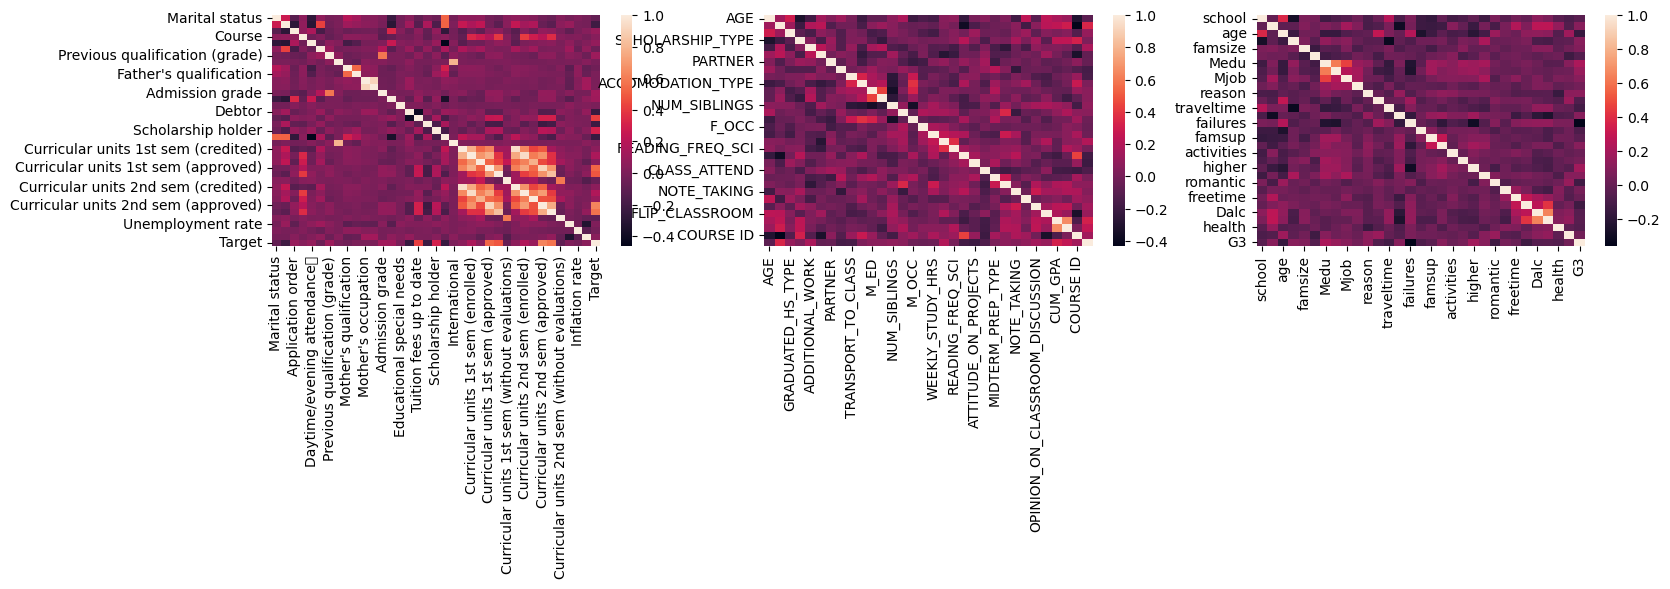

In [430]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 3))

d = student_dropout.corr(numeric_only = True)
h = student_higher.corr(numeric_only = True)
m = student_maths.corr(numeric_only = True)
sns.heatmap(d, ax=axes[0])
sns.heatmap(h, ax=axes[1])
sns.heatmap(m, ax=axes[2])


In [431]:
# Define different hyperparameter values to test
res = np.empty(3, dtype = object)
j = 0
max_depth_values = [3, 5, 7, None]
min_samples_split_values = [2, 5, 10]
results = np.empty((len(dfs), len(max_depth_values) * len(min_samples_split_values)), dtype= tuple)

# Split data into training and test sets
for i in range(len(dfs)):    
    j = 0
    X = dfs[i].drop(columns=[dfs_targets[i]])
    y = dfs[i][dfs_targets[i]]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Train and evaluate models
    for max_depth in max_depth_values:
        for min_samples_split in min_samples_split_values:
            tree = DecisionTreeClassifier(max_depth=max_depth, min_samples_split=min_samples_split, random_state=42)
            tree.fit(X_train, y_train)
            y_pred_tree = tree.predict(X_test)
            tree_accuracy = accuracy_score(y_test, y_pred_tree)
            con_matrixx = confusion_matrix(y_test, y_pred_tree)
    
            # Random Forest
            rf = RandomForestClassifier(max_depth=max_depth, min_samples_split=min_samples_split, random_state=42)
            rf.fit(X_train, y_train)
            y_pred_forest = rf.predict(X_test)
            forest_accuracy = accuracy_score(y_test, y_pred_forest)
    
            # Store results
            results[i,j] = (max_depth, min_samples_split, tree_accuracy, forest_accuracy, df_names[i])
            j += 1
print("Max Depth | Min Sample Split | Tree Acc | Forest Acc: | Dataset: \n")
column = ["Depth", 'Min Split', 'Tree Acc', 'Forest Acc', 'dataset']

Max Depth | Min Sample Split | Tree Acc | Forest Acc: | Dataset: 



In [433]:
for i in range(len(dfs)):
    res[i] = pd.DataFrame(results[i].tolist(), columns=column)

for i in res:
    display_side_by_side(i)

,Depth,Min Split,Tree Acc,Forest Acc,dataset
0,3.0,2,0.139241,0.139241,maths
1,3.0,5,0.139241,0.151899,maths
2,3.0,10,0.139241,0.139241,maths
3,5.0,2,0.151899,0.151899,maths
4,5.0,5,0.151899,0.139241,maths
5,5.0,10,0.151899,0.139241,maths
6,7.0,2,0.088608,0.113924,maths
7,7.0,5,0.088608,0.139241,maths
8,7.0,10,0.088608,0.126582,maths
9,NaN,2,0.113924,0.177215,maths


,Depth,Min Split,Tree Acc,Forest Acc,dataset
0,3.0,2,0.715254,0.710734,dropout
1,3.0,5,0.715254,0.710734,dropout
2,3.0,10,0.715254,0.710734,dropout
3,5.0,2,0.735593,0.737853,dropout
4,5.0,5,0.734463,0.738983,dropout
5,5.0,10,0.735593,0.740113,dropout
6,7.0,2,0.731073,0.754802,dropout
7,7.0,5,0.733333,0.759322,dropout
8,7.0,10,0.736723,0.761582,dropout
9,NaN,2,0.676836,0.760452,dropout


,Depth,Min Split,Tree Acc,Forest Acc,dataset
0,3.0,2,0.206897,0.137931,higher
1,3.0,5,0.206897,0.137931,higher
2,3.0,10,0.206897,0.172414,higher
3,5.0,2,0.206897,0.172414,higher
4,5.0,5,0.172414,0.206897,higher
5,5.0,10,0.275862,0.172414,higher
6,7.0,2,0.275862,0.172414,higher
7,7.0,5,0.241379,0.206897,higher
8,7.0,10,0.310345,0.172414,higher
9,NaN,2,0.206897,0.172414,higher


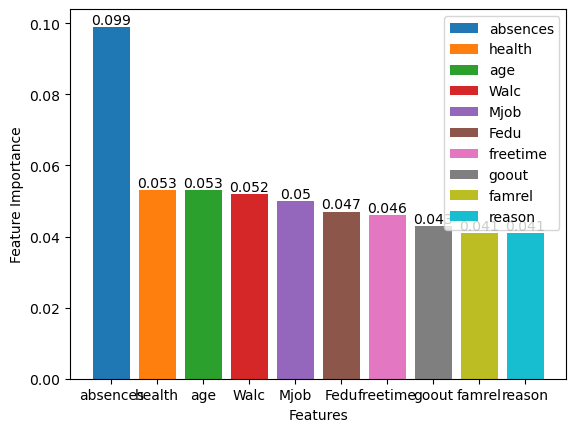

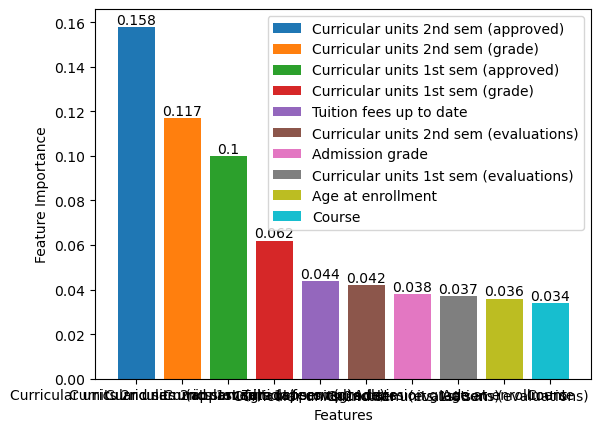

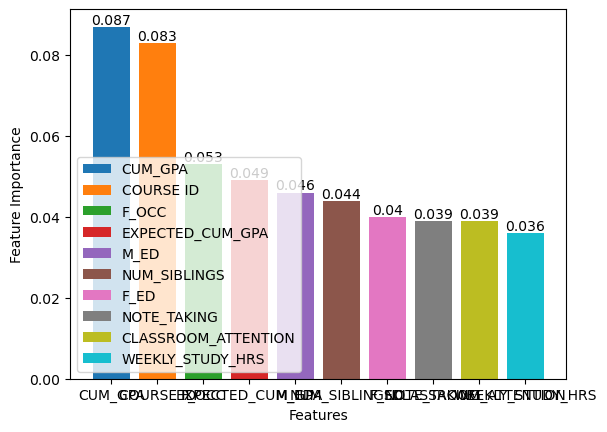

In [435]:
for i in range(len(dfs)):
    X = dfs[i].drop(columns=[dfs_targets[i]])
    y = dfs[i][dfs_targets[i]]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    rf = RandomForestClassifier(max_depth=None, min_samples_split=5, random_state=42)
    rf.fit(X_train, y_train)
    
    importances = rf.feature_importances_
    
    feature_names = X_train.columns
    feature_importances = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    
    feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
    feature_importances = feature_importances.head(10)
    
    fig, ax = plt.subplots()
    bottom = 0
    ft_imp = pd.Series(feature_importances.Importance.values,index=feature_importances.Feature).to_dict()
    
    for a, b in ft_imp.items():
        p = ax.bar(a, round(b,3), label=a, bottom=bottom)
        ax.bar_label(p)
    
    
    plt.xlabel("Features")
    plt.ylabel("Feature Importance")
    ax.legend()

plt.show()

{'maths': 0.08860759493670886,
 'dropout': 0.6632768361581921,
 'higher': 0.20689655172413793}

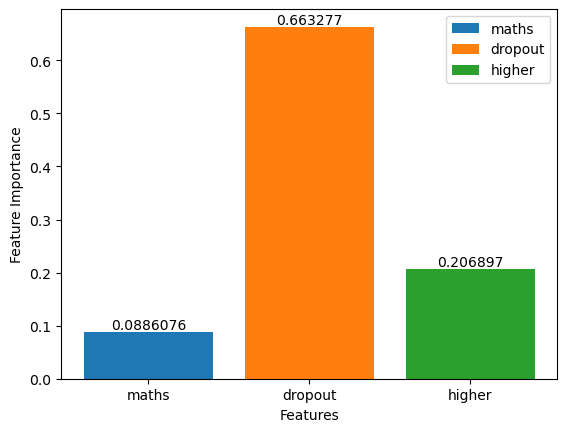

In [454]:
from sklearn.naive_bayes import MultinomialNB
scaler = MinMaxScaler()
clf = MultinomialNB()
sc = []

for i in range(len(dfs)):
    X = dfs[i].drop(columns=[dfs_targets[i]])
    y = dfs[i][dfs_targets[i]]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train = scaler.fit_transform( X_train )
    X_test= scaler.transform( X_test)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    score = clf.score(X_test, y_test)
    sc.append(score)

data_score = pd.DataFrame({'Data_Source': df_names, 'Scoring': sc})
dt_sc = pd.Series(data_score.Scoring.values,index=data_score.Data_Source).to_dict()

fig, ax = plt.subplots()
bottom = 0

for a, b in dt_sc.items():
        p = ax.bar(a, b, label=a, bottom=bottom)
        ax.bar_label(p)
    
    
plt.xlabel("Features")
plt.ylabel("Feature Importance")
ax.legend()

dt_sc
